# TruthLens — Research Paper Figures\n\nPublication-quality visualizations for the TruthLens misinformation detection system.\nAll figures saved as PNG (300 DPI) and PDF to the `viz/` directory.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Style ──────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Color palette ──────────────────────────────────────────────────────
MODEL_COLORS = {
    "Baseline RoBERTa":      "#2274A5",
    "Baseline MLM":          "#F75C03",
    "Two-Phase MLM":         "#2ECC71",
    "Two-Phase RoBERTa":     "#9B59B6",
    "Two-Phase Distil":      "#E74C3C",
}
LABEL_COLORS = {"False": "#E74C3C", "True": "#2ECC71"}
METRIC_COLORS = {"Macro-F1": "#2274A5", "Accuracy": "#F75C03", "1 − ECE": "#2ECC71"}

VIZ_DIR = Path(".")  # notebook lives in viz/
BASE = Path("..") / "baseline_model" / "baseline_outputs"
DATA_DIR = Path("..") / "data" / "processed" / "final_datasets"

def save_fig(fig, name):
    fig.savefig(VIZ_DIR / f"{name}.png")
    fig.savefig(VIZ_DIR / f"{name}.pdf")
    print(f"  Saved {name}.png and {name}.pdf")

print("Setup complete.")

Setup complete.


In [2]:
# ── Load training metrics ──────────────────────────────────────────────

RUN_MAP = {
    "Baseline RoBERTa":  BASE / "baseline_roberta"  / "logs" / "metrics_log.jsonl",
    "Baseline MLM":      BASE / "baseline_mlm"      / "logs" / "metrics_log.jsonl",
    "Two-Phase MLM":     BASE / "twophase_mlm"       / "logs" / "metrics_log.jsonl",
    "Two-Phase RoBERTa": BASE / "twophase_roberta"   / "logs" / "metrics_log.jsonl",
    "Two-Phase Distil":  BASE / "twophase_distil"    / "logs" / "metrics_log.jsonl",
}

metrics = {}
efficiency = {}

for name, path in RUN_MAP.items():
    rows = []
    with open(path) as f:
        for line in f:
            obj = json.loads(line)
            if obj.get("type") == "efficiency":
                efficiency[name] = obj
            else:
                rows.append(obj)
    df = pd.DataFrame(rows)
    # Create a global epoch for two-phase models
    if "phase" in df.columns:
        p1 = df[df["phase"] == "Phase1"]
        p2 = df[df["phase"] == "Phase2"]
        max_p1 = p1["epoch"].max() if len(p1) > 0 else 0
        df.loc[df["phase"] == "Phase2", "global_epoch"] = (
            df.loc[df["phase"] == "Phase2", "epoch"] + max_p1
        )
        df.loc[df["phase"] == "Phase1", "global_epoch"] = df.loc[df["phase"] == "Phase1", "epoch"]
        df["phase_boundary"] = max_p1
    else:
        df["global_epoch"] = df["epoch"]
        df["phase_boundary"] = None
    metrics[name] = df

# ── Load dataset ───────────────────────────────────────────────────────
dfs = {}
for split in ["train", "val", "test"]:
    dfs[split] = pd.read_parquet(DATA_DIR / f"unified_{split}.parquet")
    dfs[split]["split"] = split

dataset = pd.concat(dfs.values(), ignore_index=True)

# Pretty source names
SOURCE_MAP = {
    "coaid": "CoAID", "fakehealth": "FakeHealth",
    "fakenewsnet": "FakeNewsNet", "hover": "HOVER", "liar": "LIAR",
}
dataset["source"] = dataset["dataset"].map(SOURCE_MAP).fillna(dataset["dataset"])

print(f"Loaded {len(dataset)} samples across {dataset['source'].nunique()} sources.")
print(f"Loaded metrics for {len(metrics)} models.")
print(f"Efficiency data for: {list(efficiency.keys())}")

Loaded 56641 samples across 5 sources.
Loaded metrics for 5 models.
Efficiency data for: ['Two-Phase MLM', 'Two-Phase RoBERTa', 'Two-Phase Distil']


## Figure 1 — Dataset Composition by Source and Binary Label

  Saved fig1_dataset_composition.png and fig1_dataset_composition.pdf


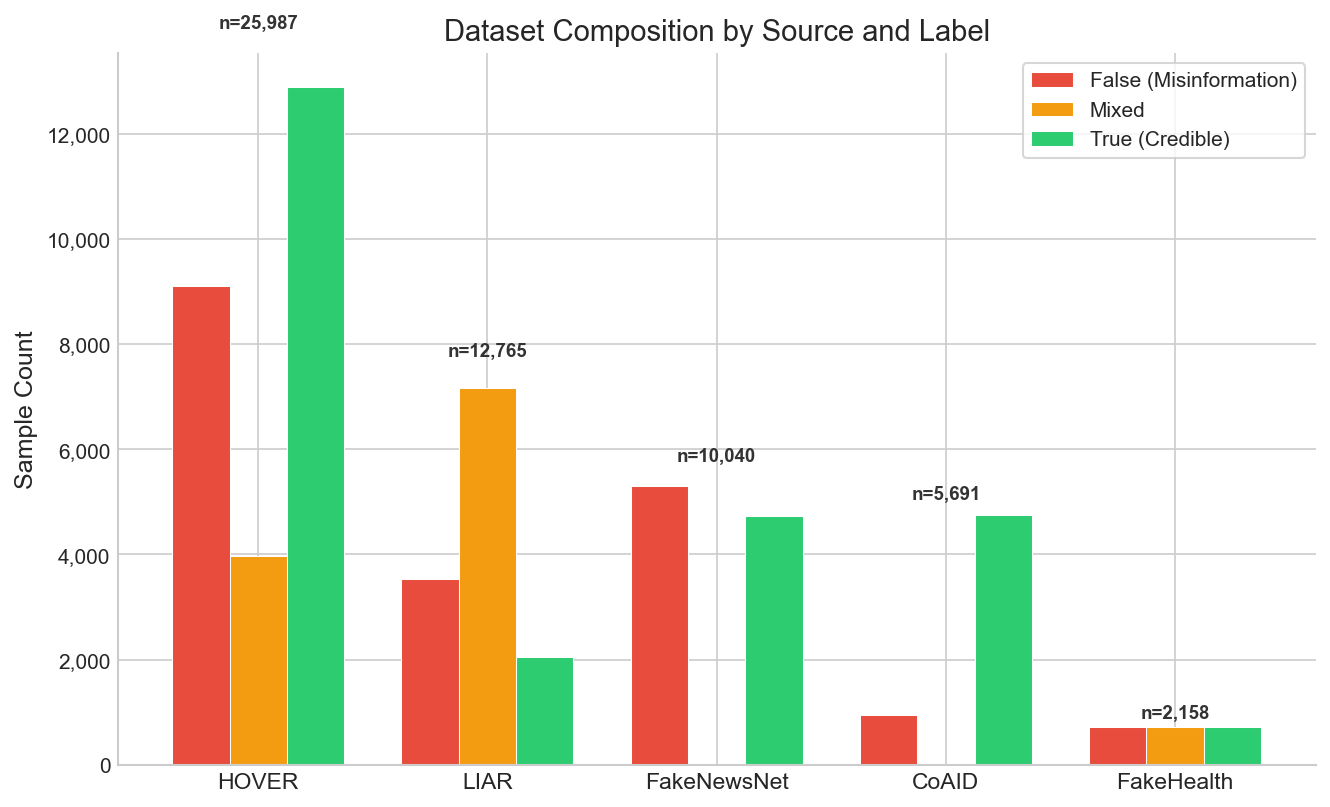

In [3]:
# For each source, use binary labels if available, otherwise use 3-way labels
# Binary: label_bin 0=False, 1=True
# 3-way:  label_3way 0=False, 1=Mixed, 2=True

categories = ["False", "Mixed", "True"]
cat_colors = ["#E74C3C", "#F39C12", "#2ECC71"]

records = []
for src in dataset["source"].unique():
    sub = dataset[dataset["source"] == src]
    has_binary = (sub["label_bin"] != -100).any()
    has_3way = (sub["label_3way"] != -100).any()

    if has_3way and not has_binary:
        # Use 3-way labels (LIAR, FakeHealth — no binary labels)
        valid = sub[sub["label_3way"] != -100]
        counts = valid["label_3way"].value_counts()
        records.append({
            "source": src,
            "False": counts.get(0, 0),
            "Mixed": counts.get(1, 0),
            "True":  counts.get(2, 0),
        })
    elif has_binary and not has_3way:
        # Use binary labels (FakeNewsNet — no 3-way labels)
        valid = sub[sub["label_bin"] != -100]
        counts = valid["label_bin"].value_counts()
        records.append({
            "source": src,
            "False": counts.get(0, 0),
            "Mixed": 0,
            "True":  counts.get(1, 0),
        })
    else:
        # Has both — use 3-way for the richer breakdown (HOVER, CoAID)
        valid = sub[sub["label_3way"] != -100]
        counts = valid["label_3way"].value_counts()
        records.append({
            "source": src,
            "False": counts.get(0, 0),
            "Mixed": counts.get(1, 0),
            "True":  counts.get(2, 0),
        })

ct = pd.DataFrame(records).set_index("source")[categories]
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(ct))
width = 0.25

for i, (col, color) in enumerate(zip(categories, cat_colors)):
    label_map = {"False": "False (Misinformation)", "Mixed": "Mixed", "True": "True (Credible)"}
    ax.bar(x + (i - 1) * width, ct[col], width, label=label_map[col],
           color=color, edgecolor="white", linewidth=0.5)

# Annotate totals
for i, src in enumerate(ct.index):
    total = ct.loc[src].sum()
    ax.text(i, ct.loc[src].max() + total * 0.04, f"n={total:,}",
            ha="center", va="bottom", fontsize=9, fontweight="bold", color="#333")

ax.set_xticks(x)
ax.set_xticklabels(ct.index, fontsize=11)
ax.set_ylabel("Sample Count")
ax.set_title("Dataset Composition by Source and Label")
ax.legend(frameon=True, fancybox=True, shadow=False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

fig.tight_layout()
save_fig(fig, "fig1_dataset_composition")
plt.show()

## Figure 2 — Content Availability by Source

  Saved fig2_content_availability.png and fig2_content_availability.pdf


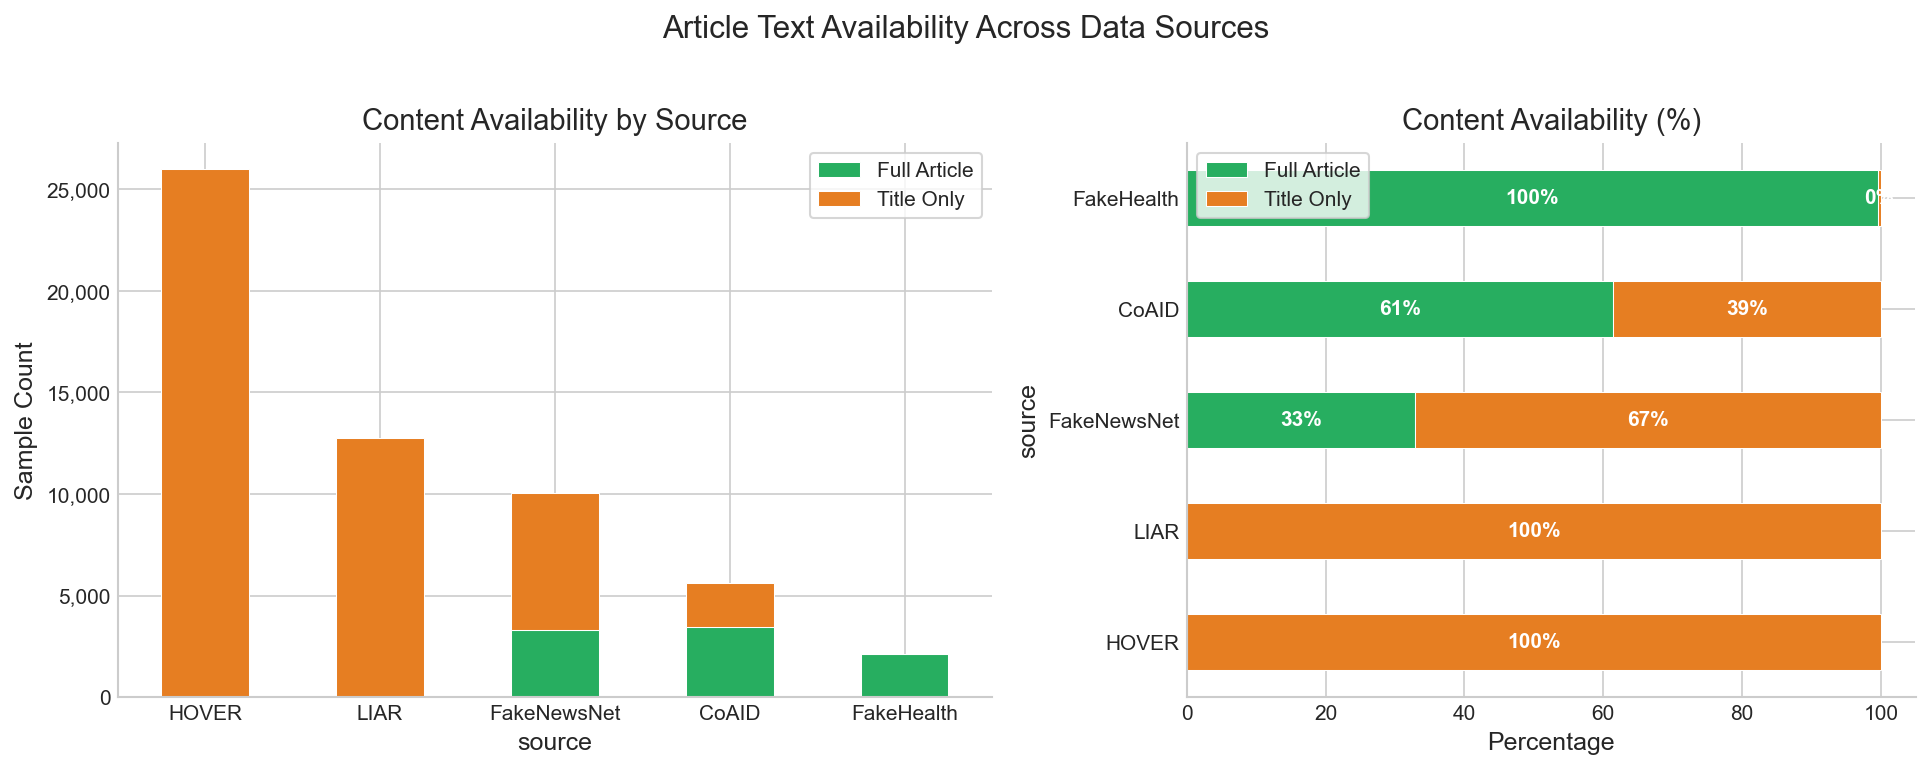

In [4]:
# Content availability: title_only vs full_article vs partial
status_map = {"title_only": "Title Only", "full_article": "Full Article", "partial_article": "Partial"}
dataset["content_label"] = dataset["content_status"].map(status_map).fillna("Other")

ct_content = pd.crosstab(dataset["source"], dataset["content_label"])
for col in ["Full Article", "Title Only", "Partial", "Other"]:
    if col not in ct_content.columns:
        ct_content[col] = 0
ct_content = ct_content[["Full Article", "Title Only"]]
# Sort by total descending
ct_content = ct_content.loc[ct_content.sum(axis=1).sort_values(ascending=False).index]

# Stacked bar — percentage
ct_pct = ct_content.div(ct_content.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.2, 1]})

# Left: absolute counts stacked
content_colors = ["#27AE60", "#E67E22"]
ct_content.plot.bar(stacked=True, ax=ax1, color=content_colors, edgecolor="white", linewidth=0.5)
ax1.set_ylabel("Sample Count")
ax1.set_title("Content Availability by Source")
ax1.set_xticklabels(ct_content.index, rotation=0, fontsize=10)
ax1.legend(frameon=True, fancybox=True)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

# Right: percentage stacked
ct_pct.plot.barh(stacked=True, ax=ax2, color=content_colors, edgecolor="white", linewidth=0.5)
for i, src in enumerate(ct_pct.index):
    full_pct = ct_pct.loc[src, "Full Article"]
    if full_pct > 3:
        ax2.text(full_pct / 2, i, f"{full_pct:.0f}%", ha="center", va="center",
                 fontsize=10, fontweight="bold", color="white")
    title_pct = ct_pct.loc[src, "Title Only"]
    ax2.text(full_pct + title_pct / 2, i, f"{title_pct:.0f}%", ha="center", va="center",
             fontsize=10, fontweight="bold", color="white")

ax2.set_xlabel("Percentage")
ax2.set_title("Content Availability (%)")
ax2.legend(frameon=True, fancybox=True)

fig.suptitle("Article Text Availability Across Data Sources", fontsize=15, y=1.02)
fig.tight_layout()
save_fig(fig, "fig2_content_availability")
plt.show()

## Figure 3 — Validation Macro-F1 Learning Curves

  Saved fig3_val_f1_curves.png and fig3_val_f1_curves.pdf


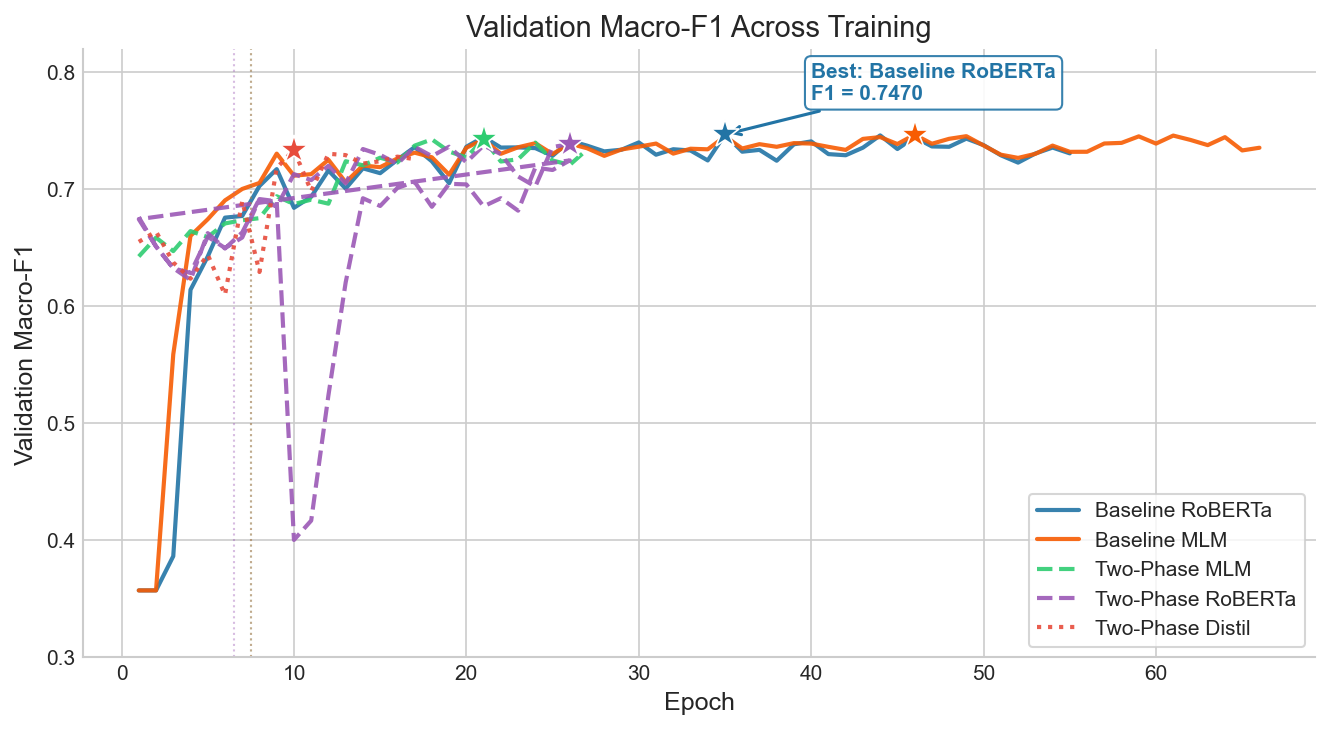

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

line_styles = {
    "Baseline RoBERTa": "-", "Baseline MLM": "-",
    "Two-Phase MLM": "--", "Two-Phase RoBERTa": "--", "Two-Phase Distil": ":",
}

# Find overall best model
best_overall_name = None
best_overall_f1 = 0

for name, df in metrics.items():
    ax.plot(df["global_epoch"], df["val_macro_f1"],
            label=name, color=MODEL_COLORS[name],
            linestyle=line_styles[name], linewidth=2, alpha=0.9)
    # Star at peak
    best_idx = df["val_macro_f1"].idxmax()
    best_epoch = df.loc[best_idx, "global_epoch"]
    best_f1 = df.loc[best_idx, "val_macro_f1"]
    ax.plot(best_epoch, best_f1, marker="*", markersize=14,
            color=MODEL_COLORS[name], markeredgecolor="white", markeredgewidth=0.8,
            zorder=5)

    if best_f1 > best_overall_f1:
        best_overall_f1 = best_f1
        best_overall_name = name
        best_overall_epoch = best_epoch

    # Phase boundary
    pb = df["phase_boundary"].iloc[0]
    if pb is not None:
        ax.axvline(x=pb + 0.5, color=MODEL_COLORS[name], linestyle=":",
                   linewidth=1, alpha=0.4)

# Annotate best overall
ax.annotate(f"Best: {best_overall_name}\nF1 = {best_overall_f1:.4f}",
            xy=(best_overall_epoch, best_overall_f1),
            xytext=(best_overall_epoch + 5, best_overall_f1 + 0.03),
            fontsize=10, fontweight="bold", color=MODEL_COLORS[best_overall_name],
            arrowprops=dict(arrowstyle="->", color=MODEL_COLORS[best_overall_name], lw=1.5),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=MODEL_COLORS[best_overall_name], alpha=0.9))

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Macro-F1")
ax.set_title("Validation Macro-F1 Across Training")
ax.legend(loc="lower right", frameon=True, fancybox=True)
ax.set_ylim(0.30, 0.82)

fig.tight_layout()
save_fig(fig, "fig3_val_f1_curves")
plt.show()

## Figure 4 — Training & Validation Loss

  Saved fig4_loss_curves.png and fig4_loss_curves.pdf


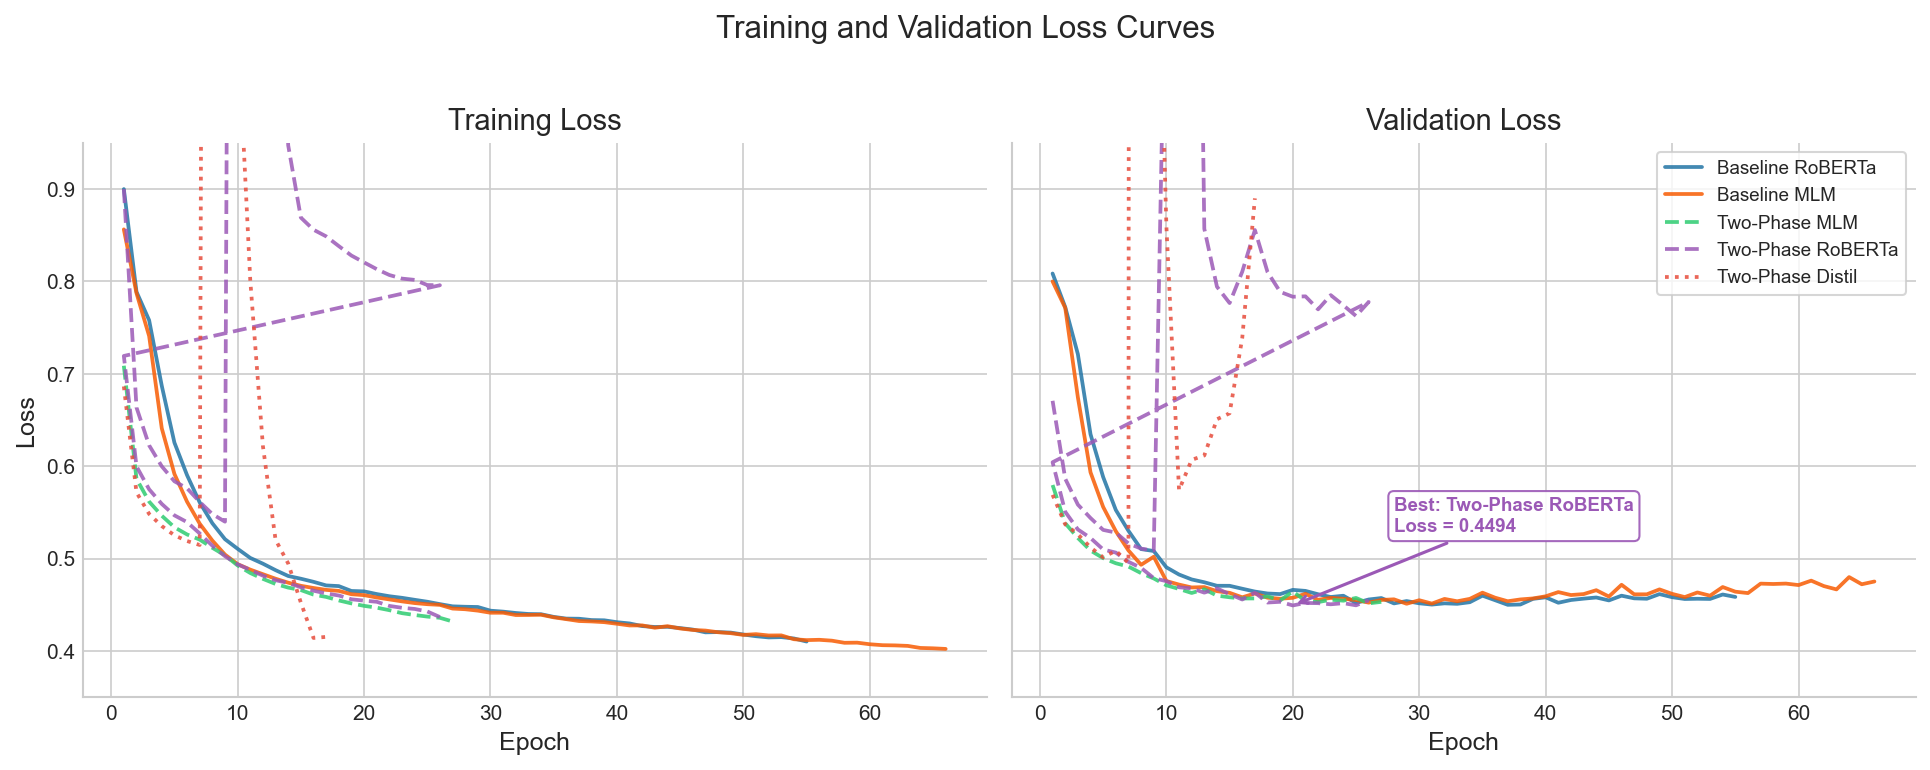

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Track best (lowest) final val loss
best_val_loss = float("inf")
best_val_name = None

for name, df in metrics.items():
    ls = line_styles[name]
    ax1.plot(df["global_epoch"], df["train_loss"], label=name,
             color=MODEL_COLORS[name], linestyle=ls, linewidth=1.8, alpha=0.85)
    ax2.plot(df["global_epoch"], df["val_loss"], label=name,
             color=MODEL_COLORS[name], linestyle=ls, linewidth=1.8, alpha=0.85)

    min_val = df["val_loss"].min()
    if min_val < best_val_loss:
        best_val_loss = min_val
        best_val_name = name
        best_val_epoch = df.loc[df["val_loss"].idxmin(), "global_epoch"]

# Annotate best val loss
ax2.annotate(f"Best: {best_val_name}\nLoss = {best_val_loss:.4f}",
             xy=(best_val_epoch, best_val_loss),
             xytext=(best_val_epoch + 8, best_val_loss + 0.08),
             fontsize=9, fontweight="bold", color=MODEL_COLORS[best_val_name],
             arrowprops=dict(arrowstyle="->", color=MODEL_COLORS[best_val_name], lw=1.5),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=MODEL_COLORS[best_val_name], alpha=0.9))

ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2.set_title("Validation Loss")
ax2.set_xlabel("Epoch")
ax2.legend(loc="upper right", frameon=True, fancybox=True, fontsize=9)

for ax in (ax1, ax2):
    ax.set_ylim(0.35, 0.95)

fig.suptitle("Training and Validation Loss Curves", fontsize=15, y=1.02)
fig.tight_layout()
save_fig(fig, "fig4_loss_curves")
plt.show()

## Figure 5 — Final Model Comparison (Macro-F1, Accuracy, 1−ECE)

  Saved fig5_model_comparison.png and fig5_model_comparison.pdf


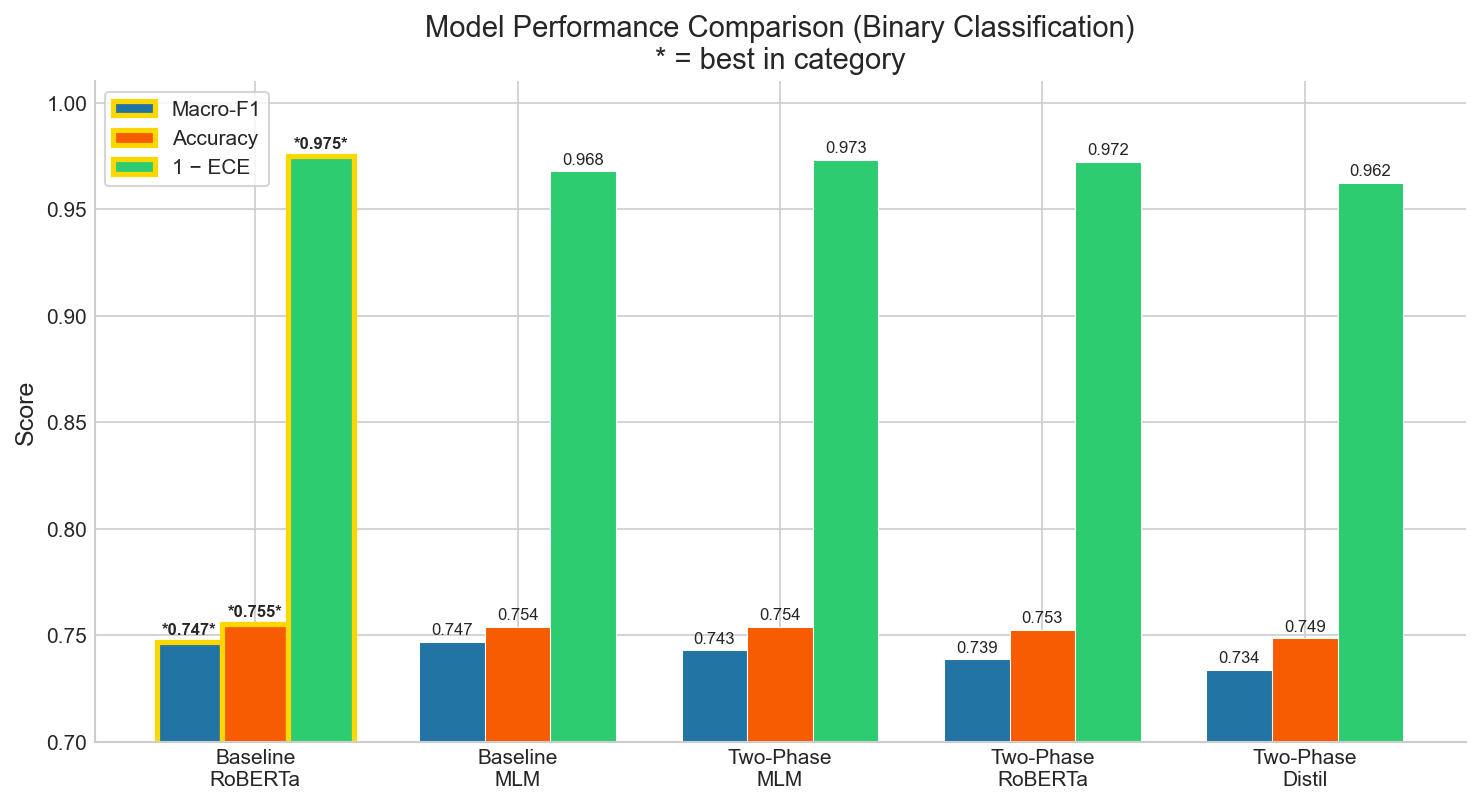

In [7]:
# Hardcoded from EXPERIMENTS.md v5 results
results = pd.DataFrame({
    "Model": ["Baseline\nRoBERTa", "Baseline\nMLM", "Two-Phase\nMLM", "Two-Phase\nRoBERTa", "Two-Phase\nDistil"],
    "Macro-F1":  [0.7470, 0.7468, 0.7429, 0.7387, 0.7338],
    "Accuracy":  [0.7554, 0.7539, 0.7540, 0.7526, 0.7485],
    "1 − ECE":   [1 - 0.0248, 1 - 0.0322, 1 - 0.0270, 1 - 0.0279, 1 - 0.0378],
})

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(results))
width = 0.25
metric_names = ["Macro-F1", "Accuracy", "1 − ECE"]

for i, metric in enumerate(metric_names):
    vals = results[metric]
    best_idx = vals.idxmax()
    bars = ax.bar(x + (i - 1) * width, vals, width,
                  label=metric, color=METRIC_COLORS[metric],
                  edgecolor="white", linewidth=0.5)
    for j, bar in enumerate(bars):
        is_best = (j == best_idx)
        weight = "bold" if is_best else "normal"
        label_text = f"{bar.get_height():.3f}"
        if is_best:
            label_text = f"*{label_text}*"
            # Gold border on best bar
            bar.set_edgecolor("#FFD700")
            bar.set_linewidth(2.5)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                label_text, ha="center", va="bottom", fontsize=8, fontweight=weight)

ax.set_xticks(x)
ax.set_xticklabels(results["Model"], fontsize=10)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison (Binary Classification)\n* = best in category")
ax.set_ylim(0.70, 1.01)
ax.legend(frameon=True, fancybox=True)

fig.tight_layout()
save_fig(fig, "fig5_model_comparison")
plt.show()

## Figure 6 — Per-Class Precision, Recall, and F1

  Saved fig6_per_class_metrics.png and fig6_per_class_metrics.pdf


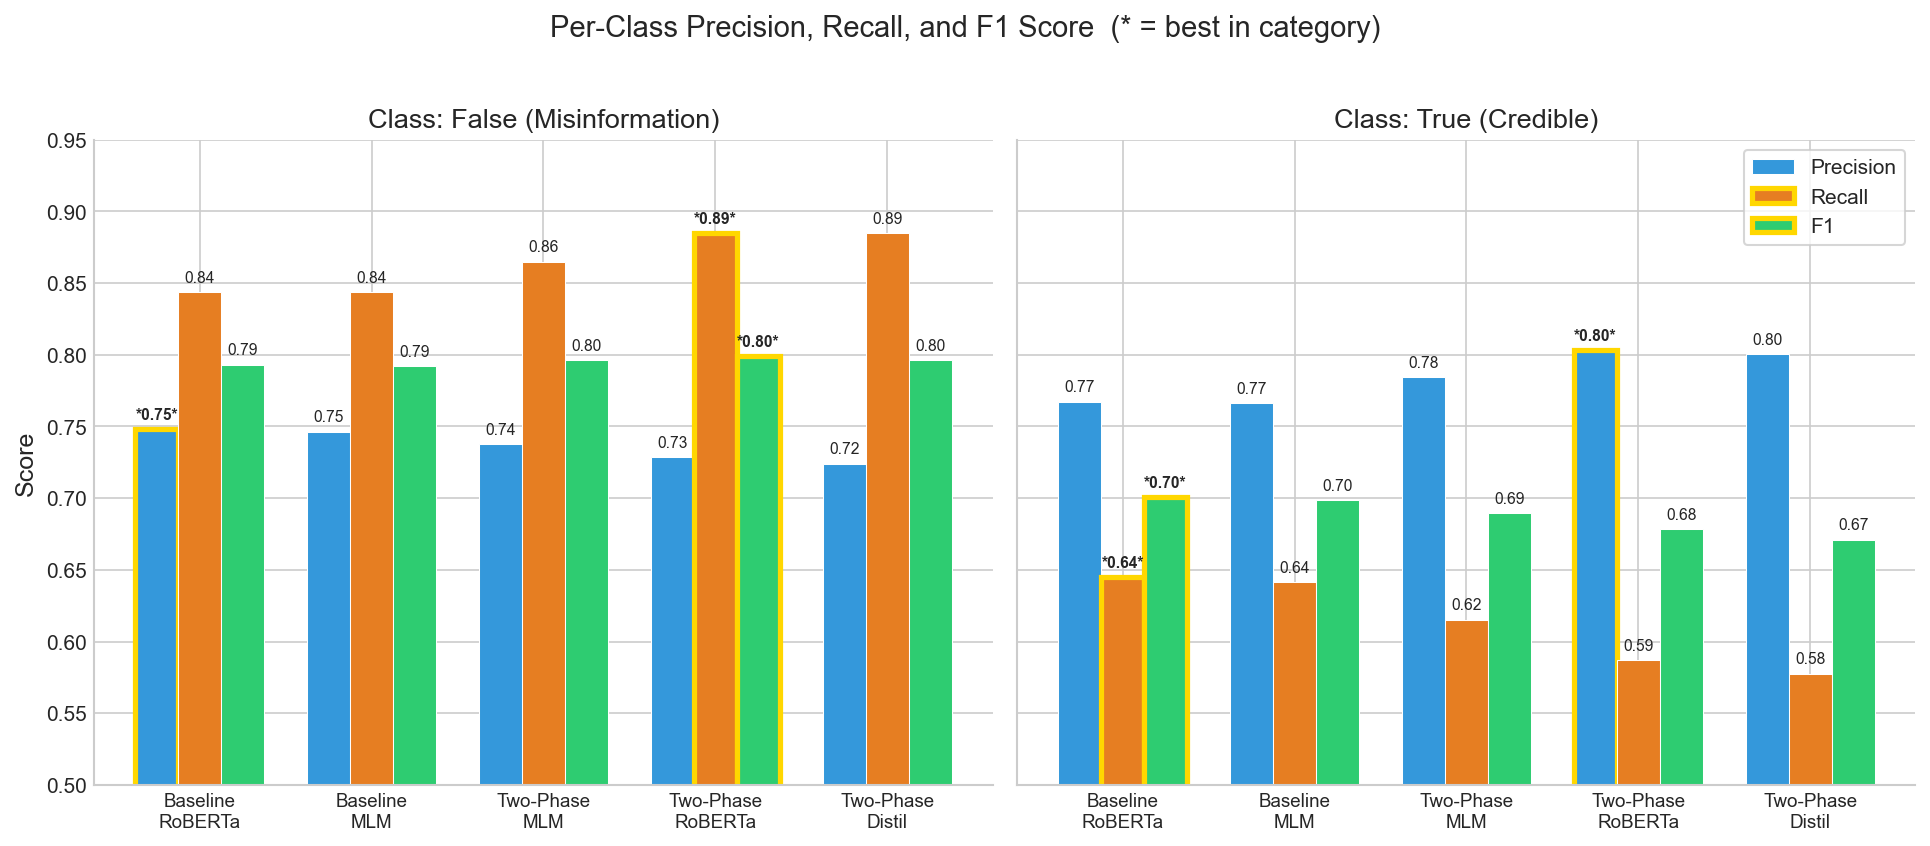

In [8]:
# Per-class metrics from EXPERIMENTS.md v5
models_short = ["Baseline\nRoBERTa", "Baseline\nMLM", "Two-Phase\nMLM", "Two-Phase\nRoBERTa", "Two-Phase\nDistil"]
per_class = {
    "false_P":  [0.7483, 0.7465, 0.7376, 0.7284, 0.7239],
    "false_R":  [0.8437, 0.8437, 0.8650, 0.8850, 0.8850],
    "false_F1": [0.7931, 0.7921, 0.7963, 0.7991, 0.7964],
    "true_P":   [0.7673, 0.7664, 0.7845, 0.8032, 0.8006],
    "true_R":   [0.6449, 0.6415, 0.6151, 0.5870, 0.5777],
    "true_F1":  [0.7008, 0.6984, 0.6895, 0.6783, 0.6711],
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
x = np.arange(len(models_short))
width = 0.25
prf_colors = ["#3498DB", "#E67E22", "#2ECC71"]  # P, R, F1

for ax, cls, prefix in [(ax1, "False (Misinformation)", "false"), (ax2, "True (Credible)", "true")]:
    for i, (suffix, label) in enumerate(zip(["_P", "_R", "_F1"], ["Precision", "Recall", "F1"])):
        vals = per_class[prefix + suffix]
        best_j = int(np.argmax(vals))
        bars = ax.bar(x + (i - 1) * width, vals, width, label=label,
                      color=prf_colors[i], edgecolor="white", linewidth=0.5)
        for j, bar in enumerate(bars):
            is_best = (j == best_j)
            weight = "bold" if is_best else "normal"
            txt = f"{bar.get_height():.2f}"
            if is_best:
                txt = f"*{txt}*"
                bar.set_edgecolor("#FFD700")
                bar.set_linewidth(2.5)
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    txt, ha="center", va="bottom", fontsize=7.5, fontweight=weight)

    ax.set_xticks(x)
    ax.set_xticklabels(models_short, fontsize=9)
    ax.set_title(f"Class: {cls}", fontsize=13)
    ax.set_ylim(0.50, 0.95)

ax1.set_ylabel("Score")
ax2.legend(frameon=True, fancybox=True, loc="upper right")
fig.suptitle("Per-Class Precision, Recall, and F1 Score  (* = best in category)", fontsize=14, y=1.02)

fig.tight_layout()
save_fig(fig, "fig6_per_class_metrics")
plt.show()

## Figure 7 — Calibration (ECE) and Inference Efficiency

  Saved fig7_calibration_efficiency.png and fig7_calibration_efficiency.pdf


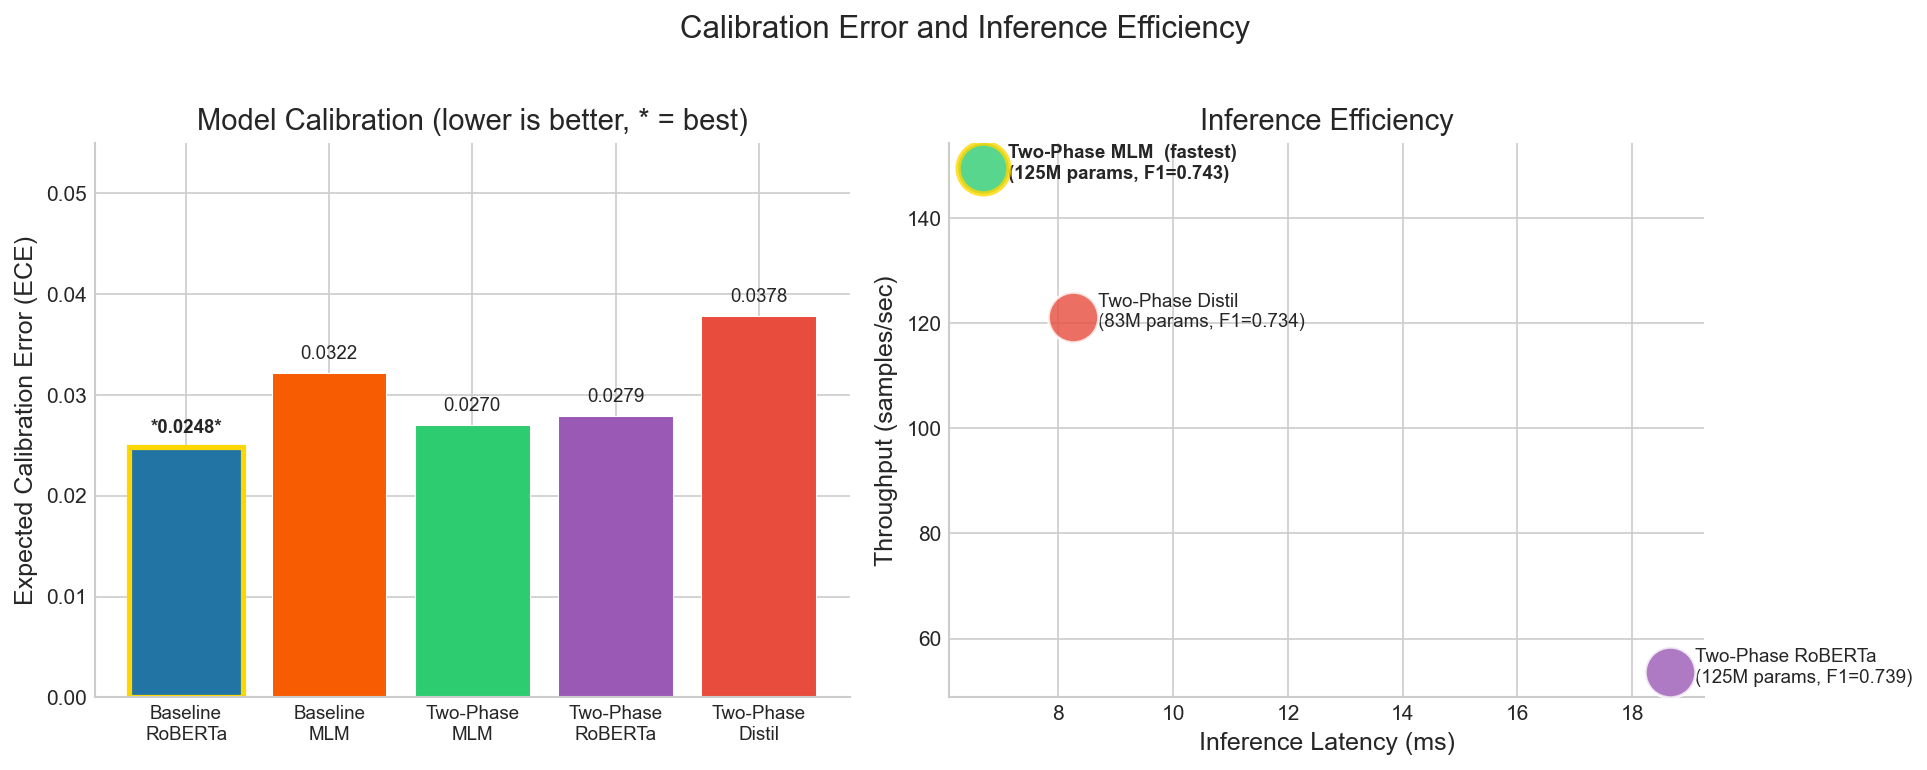

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: ECE bar chart ───────────────────────────────────────────────
model_names_short = ["Baseline\nRoBERTa", "Baseline\nMLM", "Two-Phase\nMLM", "Two-Phase\nRoBERTa", "Two-Phase\nDistil"]
model_names_full = list(MODEL_COLORS.keys())
ece_vals = [0.0248, 0.0322, 0.0270, 0.0279, 0.0378]
best_ece_idx = int(np.argmin(ece_vals))  # lowest ECE is best

bars = ax1.bar(range(len(ece_vals)), ece_vals,
               color=[MODEL_COLORS[n] for n in model_names_full],
               edgecolor="white", linewidth=0.5)
for i, (bar, val) in enumerate(zip(bars, ece_vals)):
    is_best = (i == best_ece_idx)
    weight = "bold" if is_best else "normal"
    txt = f"{val:.4f}"
    if is_best:
        txt = f"*{txt}*"
        bar.set_edgecolor("#FFD700")
        bar.set_linewidth(2.5)
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             txt, ha="center", va="bottom", fontsize=9, fontweight=weight)

ax1.set_xticks(range(len(model_names_short)))
ax1.set_xticklabels(model_names_short, fontsize=9)
ax1.set_ylabel("Expected Calibration Error (ECE)")
ax1.set_title("Model Calibration (lower is better, * = best)")
ax1.set_ylim(0, 0.055)

# ── Right: Efficiency scatter ─────────────────────────────────────────
eff_models = ["Two-Phase MLM", "Two-Phase RoBERTa", "Two-Phase Distil"]
latencies, throughputs, f1s, sizes = [], [], [], []
for name in eff_models:
    e = efficiency[name]
    latencies.append(e["inference_latency_ms"])
    throughputs.append(e["throughput_samples_sec"])
    f1s.append(e["best_val_f1"])
    sizes.append(e["params"]["total"] / 1e6)  # millions

# Bubble size proportional to F1
bubble_sizes = [(f * 800) for f in f1s]

# Best throughput
best_tp_idx = int(np.argmax(throughputs))

for i, name in enumerate(eff_models):
    ec = "#FFD700" if i == best_tp_idx else "white"
    lw = 2.5 if i == best_tp_idx else 1.5
    ax2.scatter(latencies[i], throughputs[i], s=bubble_sizes[i],
                color=MODEL_COLORS[name], alpha=0.8, edgecolors=ec,
                linewidth=lw, zorder=5)
    suffix = "  (fastest)" if i == best_tp_idx else ""
    ax2.annotate(f"{name}{suffix}\n({sizes[i]:.0f}M params, F1={f1s[i]:.3f})",
                 (latencies[i], throughputs[i]),
                 textcoords="offset points", xytext=(12, -5),
                 fontsize=9, ha="left",
                 fontweight="bold" if i == best_tp_idx else "normal")

ax2.set_xlabel("Inference Latency (ms)")
ax2.set_ylabel("Throughput (samples/sec)")
ax2.set_title("Inference Efficiency")

fig.suptitle("Calibration Error and Inference Efficiency", fontsize=15, y=1.02)
fig.tight_layout()
save_fig(fig, "fig7_calibration_efficiency")
plt.show()